               Statistical Analysis & Predictive Modelling of Particle-Dampers

This project analyzes the effect of particle damper parameters on vibration reduction using a simulation dataset of 5,000 observations.

The analysis focuses on:
- Exploratory data analysis and correlation
- Domain-informed feature engineering
- Feature importance analysis
- Statistical testing
- Interaction analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Data loading
df = pd.read_excel("Particle_damping_vibration.xlsx")

In [3]:
# Dataset Overview
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (5000, 7)

Columns:
['Particle_Diameter_m', 'Particle_Density_kg_m3', 'Number_of_Particles', 'Enclosure_Mass_kg', 'Clearance_m', 'Restitution_Coefficient', 'Vibration_Reduction_Percent']

Data types:
Particle_Diameter_m            float64
Particle_Density_kg_m3         float64
Number_of_Particles              int64
Enclosure_Mass_kg              float64
Clearance_m                    float64
Restitution_Coefficient        float64
Vibration_Reduction_Percent    float64
dtype: object

First 5 rows:


,Particle_Diameter_m,Particle_Density_kg_m3,Number_of_Particles,Enclosure_Mass_kg,Clearance_m,Restitution_Coefficient,Vibration_Reduction_Percent
0,0.001972,7597.418515,195,0.011403,0.004511,0.513661,59.721813
1,0.001931,7672.918942,164,0.014928,0.002897,0.445797,57.548744
2,0.001907,7517.400086,190,0.016012,0.001092,0.496480,56.549816
3,0.001930,6455.848603,187,0.028741,0.001665,0.334337,54.776176
4,0.001923,7462.350927,177,0.041064,0.004745,0.364022,53.597649


In [4]:
# Correlation Analysis(Pearson correlation)
correlation = (
    df.corr(numeric_only=True)["Vibration_Reduction_Percent"]
    .sort_values(ascending=False)
)

print("Correlation with Vibration Reduction:")
display(correlation)

Correlation with Vibration Reduction:


Vibration_Reduction_Percent    1.000000
Particle_Diameter_m            0.662879
Number_of_Particles            0.423363
Particle_Density_kg_m3         0.237273
Clearance_m                    0.026965
Enclosure_Mass_kg             -0.097442
Restitution_Coefficient       -0.329693
Name: Vibration_Reduction_Percent, dtype: float64

                     Exploratory Visualization

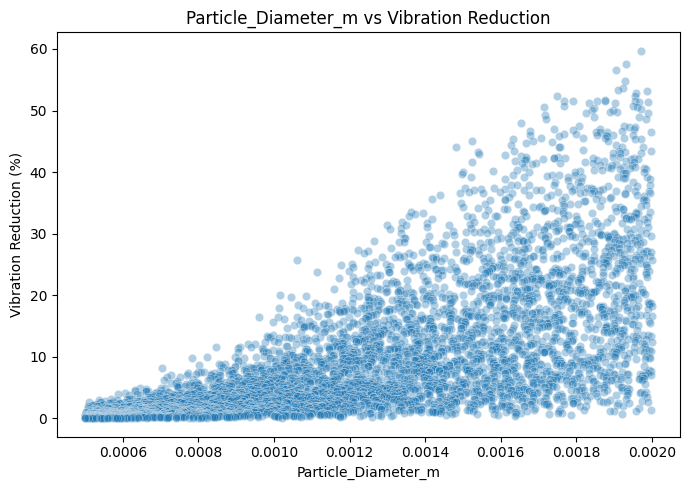

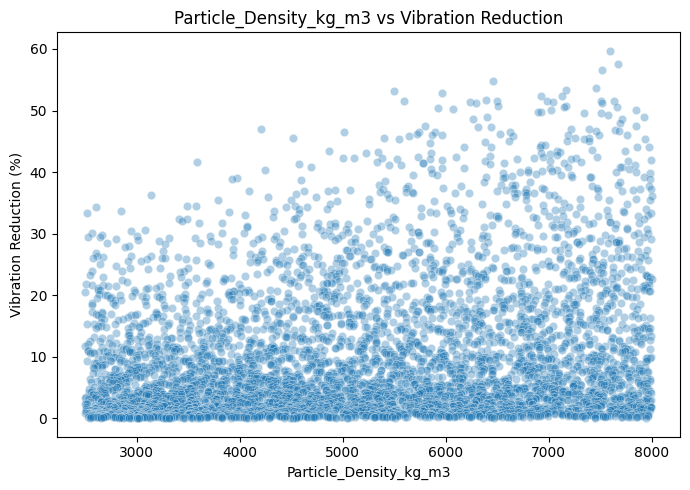

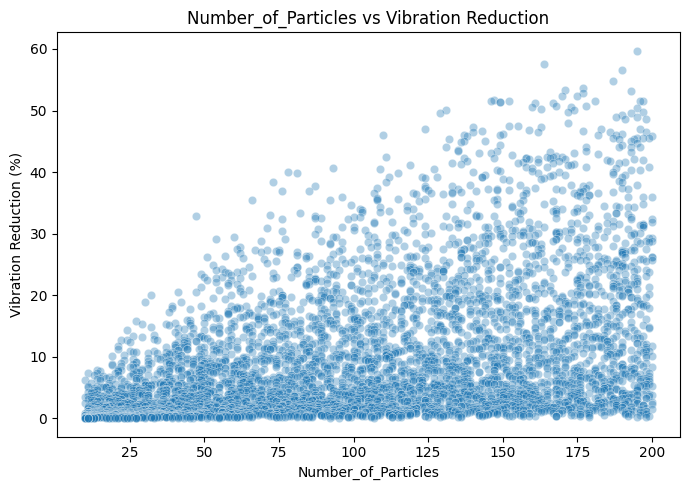

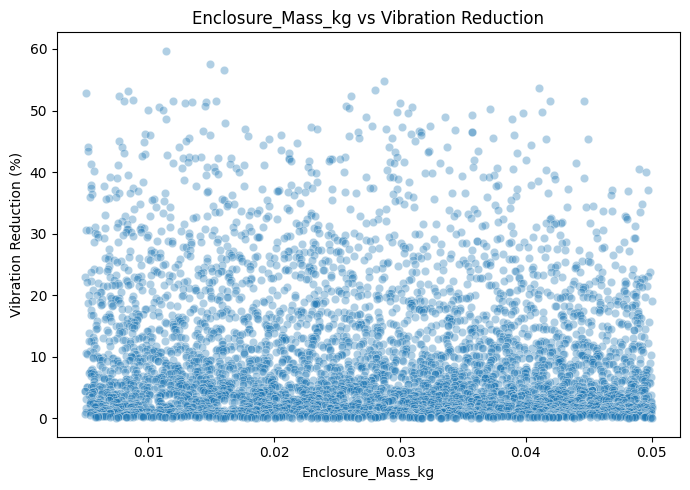

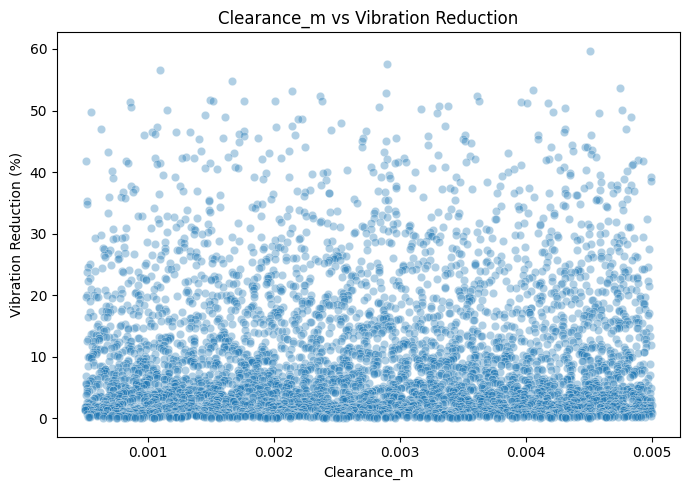

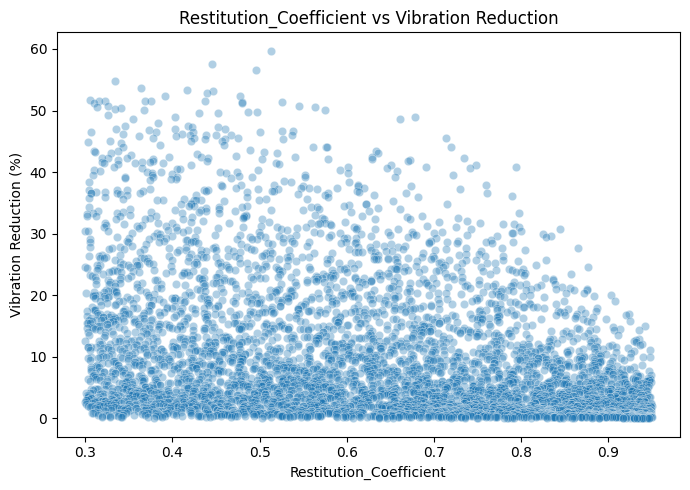

In [5]:
X = [
    'Particle_Diameter_m',
    'Particle_Density_kg_m3',
    'Number_of_Particles',
    'Enclosure_Mass_kg',
    'Clearance_m',
    'Restitution_Coefficient'
]

y = 'Vibration_Reduction_Percent'

for feature in X:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x=feature, y=y, alpha=0.35)
    plt.title(f'{feature} vs Vibration Reduction')
    plt.xlabel(feature)
    plt.ylabel('Vibration Reduction (%)')
    plt.tight_layout()
    plt.show()

                       Feature Engineering 
The original variables describe individual particle and enclosure characteristics. To capture physically meaningful aggregate effects, two additional features are derived:

- **Total Particle Mass** — combines particle diameter, particle density, and number of particles.
- **Particle-to-Enclosure Mass Ratio** — represents the particle mass relative to the enclosure mass.

These engineered features are used to examine whether aggregate physical quantities provide a stronger representation of vibration reduction than the individual parameters alone.

In [6]:
df["Total_Particle_Mass_kg"] = (
    df["Number_of_Particles"]
    * (np.pi / 6)
    * df["Particle_Diameter_m"]**3
    * df["Particle_Density_kg_m3"]
)

df["Particle_to_Enclosure_Mass_Ratio"] = (
    df["Total_Particle_Mass_kg"] / df["Enclosure_Mass_kg"]
)

print("\nCorrelation of engineered features with target:")
print(
    df[
        [
            "Total_Particle_Mass_kg",
            "Particle_to_Enclosure_Mass_Ratio",
            "Vibration_Reduction_Percent"
        ]
    ].corr()["Vibration_Reduction_Percent"]
)


Correlation of engineered features with target:
Total_Particle_Mass_kg              0.872357
Particle_to_Enclosure_Mass_Ratio    0.671153
Vibration_Reduction_Percent         1.000000
Name: Vibration_Reduction_Percent, dtype: float64


                       Feature Importance
Raw Features: A Random Forest Regressor is used to estimate the relative importance of the original input variables in predicting vibration reduction.
Engineered Features: The feature importance is recalculated after introducing the engineered particle-mass features.

Comparing the raw and engineered feature sets helps evaluate whether physically meaningful aggregate variables provide a better representation of the factors associated with vibration reduction.

In [7]:
raw_features = [
    "Particle_Diameter_m",
    "Particle_Density_kg_m3",
    "Number_of_Particles",
    "Enclosure_Mass_kg",
    "Clearance_m",
    "Restitution_Coefficient"
]

X_raw = df[raw_features]
y = df["Vibration_Reduction_Percent"]

model_raw = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model_raw.fit(X_raw, y)

raw_importance = pd.Series(
    model_raw.feature_importances_,
    index=raw_features
).sort_values(ascending=False)

print("RAW FEATURE IMPORTANCE")
print(raw_importance)

RAW FEATURE IMPORTANCE
Particle_Diameter_m        0.471766
Number_of_Particles        0.253954
Restitution_Coefficient    0.175721
Particle_Density_kg_m3     0.087445
Enclosure_Mass_kg          0.007607
Clearance_m                0.003507
dtype: float64


In [8]:
engineered_features = [
    "Total_Particle_Mass_kg",
    "Particle_to_Enclosure_Mass_Ratio"
]

X_eng = df[engineered_features]

model_eng = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model_eng.fit(X_eng, y)

eng_importance = pd.Series(
    model_eng.feature_importances_,
    index=engineered_features
).sort_values(ascending=False)

print("\nENGINEERED FEATURE IMPORTANCE")
print(eng_importance)


ENGINEERED FEATURE IMPORTANCE
Total_Particle_Mass_kg              0.89006
Particle_to_Enclosure_Mass_Ratio    0.10994
dtype: float64


                       Distribution Analysis

In [9]:
# Skewness
print("\nSKEWNESS")
print(df.skew(numeric_only=True).sort_values(ascending=False))

# Target percentiles
target = "Vibration_Reduction_Percent"

print("\nTARGET PERCENTILES")
print(
    df[target].quantile(
        [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]
    )
)


SKEWNESS
Particle_to_Enclosure_Mass_Ratio    4.121510
Total_Particle_Mass_kg              1.986918
Vibration_Reduction_Percent         1.505009
Particle_Density_kg_m3              0.016323
Number_of_Particles                 0.009227
Clearance_m                         0.003803
Restitution_Coefficient             0.002590
Enclosure_Mass_kg                  -0.009335
Particle_Diameter_m                -0.013131
dtype: float64

TARGET PERCENTILES
0.00     0.011525
0.01     0.134693
0.05     0.395998
0.10     0.734626
0.25     2.066078
0.50     6.094314
0.75    15.220495
0.90    26.371322
0.95    33.922795
0.99    46.569574
1.00    59.721813
Name: Vibration_Reduction_Percent, dtype: float64


The distributions of the variables are examined using skewness and percentile summaries.

The target variable is positively skewed, with most observations concentrated toward lower vibration-reduction values and a smaller number of observations showing substantially higher reduction.

                       Quantile/Bin Analysis

In [10]:
for feature in raw_features:

    df["bin"] = pd.qcut(
        df[feature],
        q=5,
        duplicates="drop"
    )

    summary = (
        df.groupby("bin", observed=True)[target]
        .agg(
            Count="count",
            Mean="mean",
            Median="median",
            Std="std"
        )
        .round(2)
    )

    print(f"\n{feature}")
    display(summary)


Particle_Diameter_m


,Count,Mean,Median,Std
bin,,,,
"(-0.0005, 0.000809]",1000,1.51,1.07,1.41
"(0.000809, 0.00111]",1000,4.43,3.62,3.68
"(0.00111, 0.0014]",1000,9.48,8.06,6.90
"(0.0014, 0.00169]",1000,14.81,12.45,10.31
"(0.00169, 0.002]",1000,21.41,19.80,13.30



Particle_Density_kg_m3


,Count,Mean,Median,Std
bin,,,,
"(2500.29, 3579.625]",1000,6.80,3.93,7.43
"(3579.625, 4667.728]",1000,8.29,5.29,8.71
"(4667.728, 5787.077]",1000,10.50,6.44,10.56
"(5787.077, 6899.364]",1000,11.97,7.80,12.05
"(6899.364, 7999.455]",1000,14.08,9.37,13.47



Number_of_Particles


...

,Count,Mean,Median,Std
bin,,,,
"(0.004, 0.0142]",1000,11.38,6.90,11.75
"(0.0142, 0.0231]",1000,11.25,6.67,11.48
"(0.0231, 0.0322]",1000,10.90,6.45,11.52
"(0.0322, 0.0413]",1000,9.84,6.10,10.53
"(0.0413, 0.05]",1000,8.26,4.58,9.08



Clearance_m


,Count,Mean,Median,Std
bin,,,,
"(-0.0005, 0.00142]",1000,9.66,5.78,10.46
"(0.00142, 0.00232]",1000,10.51,6.18,11.12
"(0.00232, 0.0032]",1000,10.46,6.40,10.90
"(0.0032, 0.00412]",1000,10.08,6.00,10.81
"(0.00412, 0.005]",1000,10.94,6.20,11.53



Restitution_Coefficient


,Count,Mean,Median,Std
bin,,,,
"(0.299, 0.428]",1000,14.79,11.03,13.07
"(0.428, 0.559]",1000,12.89,8.58,12.34
"(0.559, 0.688]",1000,11.20,7.61,10.57
"(0.688, 0.819]",1000,8.30,4.97,8.75
"(0.819, 0.95]",1000,4.46,2.73,5.06


                                                  Statistical Analysis

The Kruskal–Wallis test is used to determine whether the distribution of vibration reduction differs significantly across five quantile-based groups of each input parameter.

A significance level of 0.05 is used.

In [11]:
for feature in raw_features:

    groups = pd.qcut(
        df[feature],
        q=5,
        duplicates="drop"
    )

    samples = [
        df.loc[groups == group, target].values
        for group in groups.cat.categories
    ]

    statistic, p_value = kruskal(*samples)

    print(f"{feature}")
    print(f"p-value = {p_value:.6e}")

    if p_value < 0.05:
        print("Result: Statistically significant difference across groups.")
    else:
        print("Result: No statistically significant difference across groups.")

    print(" ")

Particle_Diameter_m
p-value = 0.000000e+00
Result: Statistically significant difference across groups.
 
Particle_Density_kg_m3
p-value = 3.075430e-48
Result: Statistically significant difference across groups.
 
Number_of_Particles
p-value = 4.064576e-218
Result: Statistically significant difference across groups.
 
Enclosure_Mass_kg
p-value = 6.371617e-10
Result: Statistically significant difference across groups.
 
Clearance_m
p-value = 3.590356e-01
Result: No statistically significant difference across groups.
 
Restitution_Coefficient
p-value = 2.155433e-133
Result: Statistically significant difference across groups.
 


                     Interaction Analysis

Individual parameter analysis does not always capture how two variables work together.

The following analysis examines the combined effect of (1) total particle mass and restitution coefficient (2) Total particle Mass and Enclosure Mass on vibration reduction. Both variables are divided into three quantile-based groups, and the mean vibration reduction is calculated for each combination.

In [12]:
# Particle Mass x Restitution Coefficient
mass_group = pd.qcut(
    df["Total_Particle_Mass_kg"],
    q=3,
    labels=["Low Mass", "Medium Mass", "High Mass"]
)

restitution_group = pd.qcut(
    df["Restitution_Coefficient"],
    q=3,
    labels=["Low Restitution", "Medium Restitution", "High Restitution"]
)

interaction = pd.pivot_table(
    df,
    values="Vibration_Reduction_Percent",
    index=restitution_group,
    columns=mass_group,
    aggfunc="mean"
)

display(interaction.round(2))

Total_Particle_Mass_kg,Low Mass,Medium Mass,High Mass
Restitution_Coefficient,,,
Low Restitution,2.49,10.27,29.41
Medium Restitution,1.68,7.57,23.61
High Restitution,0.84,3.91,13.04


In [13]:
## Particle Mass x Enclosure mass
mass_group = pd.qcut(
    df["Total_Particle_Mass_kg"],
    q=3,
    labels=["Low Mass", "Medium Mass", "High Mass"]
)

enclosure_group = pd.qcut(
    df["Enclosure_Mass_kg"],
    q=3,
    labels=["Low Enclosure Mass", "Medium Enclosure Mass", "High Enclosure Mass"]
)

interaction_2 = pd.pivot_table(
    df,
    values="Vibration_Reduction_Percent",
    index=enclosure_group,
    columns=mass_group,
    aggfunc="mean"
)

display(interaction_2.round(2))

Total_Particle_Mass_kg,Low Mass,Medium Mass,High Mass
Enclosure_Mass_kg,,,
Low Enclosure Mass,1.81,7.70,23.57
Medium Enclosure Mass,1.68,7.81,22.77
High Enclosure Mass,1.49,6.45,19.58


                       Findings and Conclusions
- Particle diameter and number of particles showed the strongest positive relationships with vibration reduction, while restitution coefficient showed a negative relationship; clearance had comparatively little effect.
- Feature engineering significantly improved representation of the damping configuration, with total particle mass showing the strongest association with vibration reduction.
- Statistical analysis indicated that most parameters had significant effects, whereas clearance was not statistically significant.
- Interaction analysis showed that the effect of particle mass depends on parameters such as restitution coefficient and enclosure mass, indicating combined and potentially nonlinear effects.
- Overall, the analysis identifies total particle mass as the most informative parameter and provides a basis for using nonlinear machine-learning models to predict vibration reduction.